<a href="https://colab.research.google.com/github/nitheensakthe/DataScience-Hackthon-Project-1/blob/main/54_SMART_CITY_NITHEEN_SAKTHE_PE_24CS316.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/smart_city_weather_traffic_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Timestamp,Road_ID,Traffic_Speed,Traffic_Volume,Rainfall,Weather_Condition,Time_of_Day,Weekday
0,2025-05-11 06:00:00,R20,27.50,412,0.71,Light Rain,Morning,Sunday
1,2025-04-08 14:00:00,R16,43.00,926,1.79,Light Rain,Afternoon,Tuesday
2,2025-02-06 01:30:00,R03,43.75,497,0.12,Cloudy,Night,Thursday
3,2025-04-09 19:00:00,R15,40.82,1112,0.03,Clear,Evening,Wednesday
4,2025-04-05 04:30:00,R06,44.06,612,0.02,Clear,Night,Saturday


In [2]:
# Display basic information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          10000 non-null  object 
 1   Road_ID            10000 non-null  object 
 2   Traffic_Speed      10000 non-null  float64
 3   Traffic_Volume     10000 non-null  int64  
 4   Rainfall           10000 non-null  float64
 5   Weather_Condition  10000 non-null  object 
 6   Time_of_Day        10000 non-null  object 
 7   Weekday            10000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 625.1+ KB


None

In [3]:
# Check for missing values
display(df.isnull().sum())

,0
Timestamp,0
Road_ID,0
Traffic_Speed,0
Traffic_Volume,0
Rainfall,0
Weather_Condition,0
Time_of_Day,0
Weekday,0


In [4]:
# Convert 'Timestamp' column to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Display the DataFrame information again to confirm the data type change
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          10000 non-null  datetime64[ns]
 1   Road_ID            10000 non-null  object        
 2   Traffic_Speed      10000 non-null  float64       
 3   Traffic_Volume     10000 non-null  int64         
 4   Rainfall           10000 non-null  float64       
 5   Weather_Condition  10000 non-null  object        
 6   Time_of_Day        10000 non-null  object        
 7   Weekday            10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 625.1+ KB


None

In [5]:
# Convert categorical columns to 'category' dtype
for col in ['Road_ID', 'Weather_Condition', 'Time_of_Day', 'Weekday']:
    df[col] = df[col].astype('category')

# Display the DataFrame information again to confirm the data type changes
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          10000 non-null  datetime64[ns]
 1   Road_ID            10000 non-null  category      
 2   Traffic_Speed      10000 non-null  float64       
 3   Traffic_Volume     10000 non-null  int64         
 4   Rainfall           10000 non-null  float64       
 5   Weather_Condition  10000 non-null  category      
 6   Time_of_Day        10000 non-null  category      
 7   Weekday            10000 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(2), int64(1)
memory usage: 353.1 KB


None

In [6]:
# Check unique values for categorical columns to identify inconsistencies
print("Unique values for Road_ID:", df['Road_ID'].unique())
print("Unique values for Weather_Condition:", df['Weather_Condition'].unique())
print("Unique values for Time_of_Day:", df['Time_of_Day'].unique())
print("Unique values for Weekday:", df['Weekday'].unique())

Unique values for Road_ID: ['R20', 'R16', 'R03', 'R15', 'R06', ..., 'R02', 'R04', 'R09', 'R11', 'R07']
Length: 20
Categories (20, object): ['R01', 'R02', 'R03', 'R04', ..., 'R17', 'R18', 'R19', 'R20']
Unique values for Weather_Condition: ['Light Rain', 'Cloudy', 'Clear', 'Heavy Rain']
Categories (4, object): ['Clear', 'Cloudy', 'Heavy Rain', 'Light Rain']
Unique values for Time_of_Day: ['Morning', 'Afternoon', 'Night', 'Evening']
Categories (4, object): ['Afternoon', 'Evening', 'Morning', 'Night']
Unique values for Weekday: ['Sunday', 'Tuesday', 'Thursday', 'Wednesday', 'Saturday', 'Monday', 'Friday']
Categories (7, object): ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
                         'Wednesday']


In [7]:
# Display descriptive statistics for numerical columns
display(df[['Traffic_Speed', 'Traffic_Volume', 'Rainfall']].describe())

,Traffic_Speed,Traffic_Volume,Rainfall
count,10000.000000,10000.000000,10000.000000
mean,37.498902,797.639900,1.193281
std,7.963053,231.215829,3.194565
min,8.000000,150.000000,0.000000
25%,32.547500,627.000000,0.020000
50%,38.255000,793.000000,0.070000
75%,43.140000,954.000000,0.380000
max,61.090000,1521.000000,39.990000


In [9]:
# Group by Weather_Condition and calculate the mean of Traffic_Speed, Traffic_Volume, and Rainfall
weather_impact = df.groupby('Weather_Condition', observed=False)[['Traffic_Speed', 'Traffic_Volume', 'Rainfall']].mean().reset_index()

display(weather_impact)

,Weather_Condition,Traffic_Speed,Traffic_Volume,Rainfall
0,Clear,40.505815,798.138953,0.036470
1,Cloudy,38.523482,790.750838,0.119736
2,Heavy Rain,23.324068,819.679379,9.903475
3,Light Rain,33.569824,797.916207,2.439283


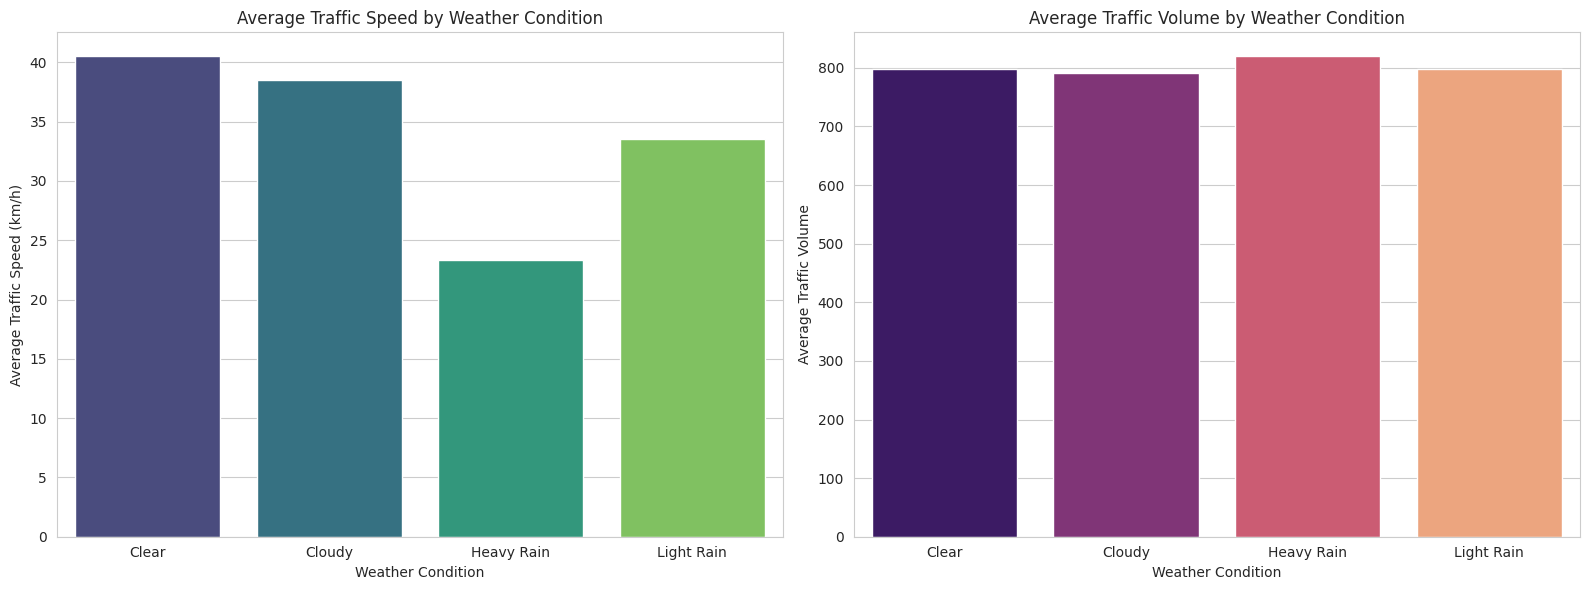

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Traffic Speed by Weather Condition
sns.barplot(x='Weather_Condition', y='Traffic_Speed', data=weather_impact.sort_values(by='Traffic_Speed', ascending=False), ax=axes[0], palette='viridis', hue='Weather_Condition', legend=False)
axes[0].set_title('Average Traffic Speed by Weather Condition')
axes[0].set_ylabel('Average Traffic Speed (km/h)')
axes[0].set_xlabel('Weather Condition')

# Plot 2: Average Traffic Volume by Weather Condition
sns.barplot(x='Weather_Condition', y='Traffic_Volume', data=weather_impact.sort_values(by='Traffic_Volume', ascending=False), ax=axes[1], palette='magma', hue='Weather_Condition', legend=False)
axes[1].set_title('Average Traffic Volume by Weather Condition')
axes[1].set_ylabel('Average Traffic Volume')
axes[1].set_xlabel('Weather Condition')

plt.tight_layout()
plt.show()

In [12]:
# Group by Weather_Condition, Time_of_Day, and Weekday and calculate mean traffic speed and volume
traffic_patterns_by_temporal = df.groupby(['Weather_Condition', 'Time_of_Day', 'Weekday'], observed=False)[['Traffic_Speed', 'Traffic_Volume']].mean().reset_index()

display(traffic_patterns_by_temporal.head())

,Weather_Condition,Time_of_Day,Weekday,Traffic_Speed,Traffic_Volume
0,Clear,Afternoon,Friday,41.732022,741.494382
1,Clear,Afternoon,Monday,42.359835,730.219780
2,Clear,Afternoon,Saturday,43.424971,622.878613
3,Clear,Afternoon,Sunday,43.874873,608.474684
4,Clear,Afternoon,Thursday,41.858081,753.645349


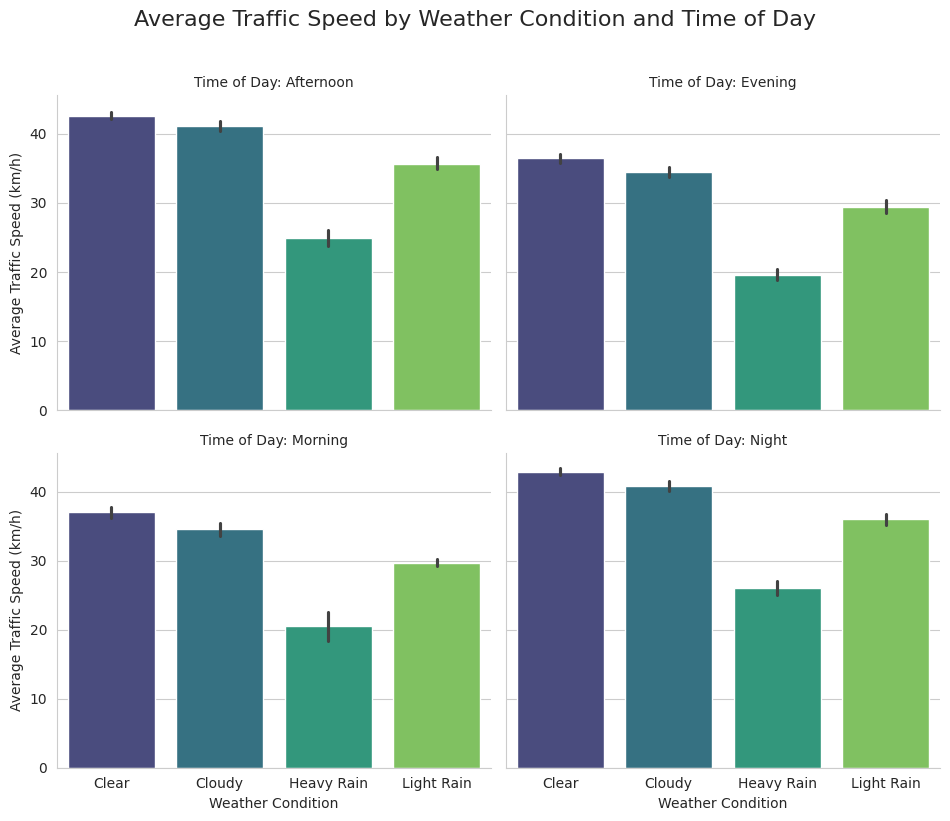

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize average Traffic_Speed by Weather_Condition and Time_of_Day
g = sns.catplot(x='Weather_Condition', y='Traffic_Speed', col='Time_of_Day', data=traffic_patterns_by_temporal, kind='bar', palette='viridis', col_wrap=2, height=4, aspect=1.2, hue='Weather_Condition', legend=False)
g.set_axis_labels("Weather Condition", "Average Traffic Speed (km/h)")
g.set_titles("Time of Day: {col_name}")
plt.suptitle('Average Traffic Speed by Weather Condition and Time of Day', y=1.02, fontsize=16) # Corrected: plt.suptitle instead of g.suptitle
plt.tight_layout()
plt.show()

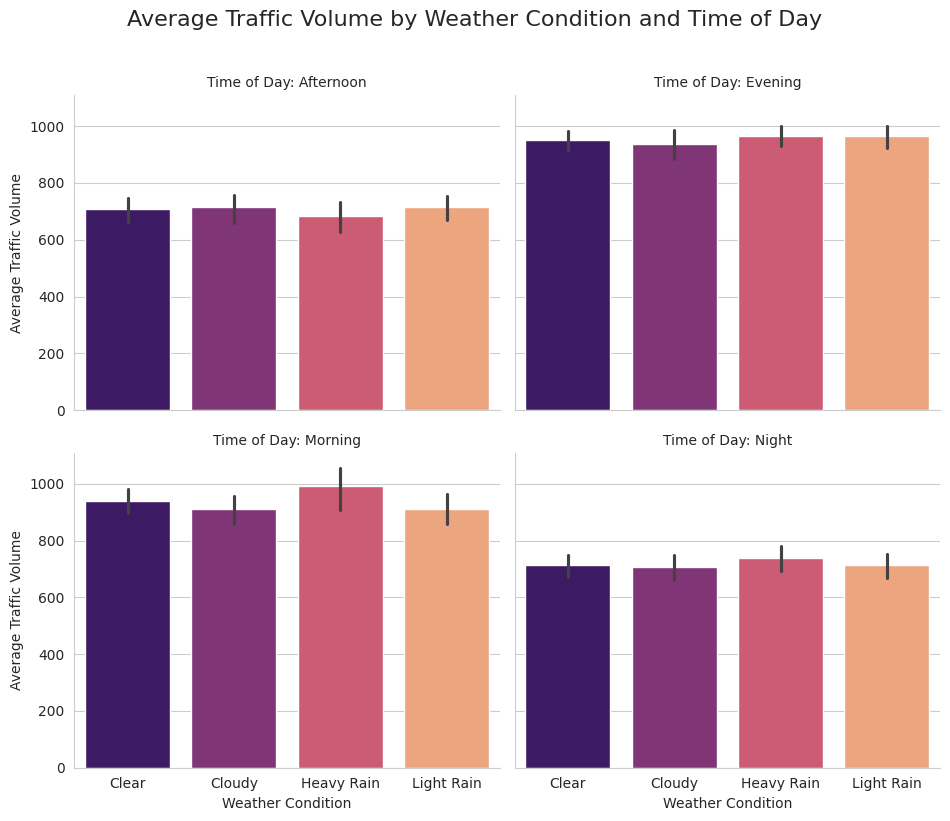

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize average Traffic_Volume by Weather_Condition and Time_of_Day
g = sns.catplot(x='Weather_Condition', y='Traffic_Volume', col='Time_of_Day', data=traffic_patterns_by_temporal, kind='bar', palette='magma', col_wrap=2, height=4, aspect=1.2, hue='Weather_Condition', legend=False)
g.set_axis_labels("Weather Condition", "Average Traffic Volume")
g.set_titles("Time of Day: {col_name}")
plt.suptitle('Average Traffic Volume by Weather Condition and Time of Day', y=1.02, fontsize=16) # Corrected: plt.suptitle instead of g.suptitle
plt.tight_layout()
plt.show()

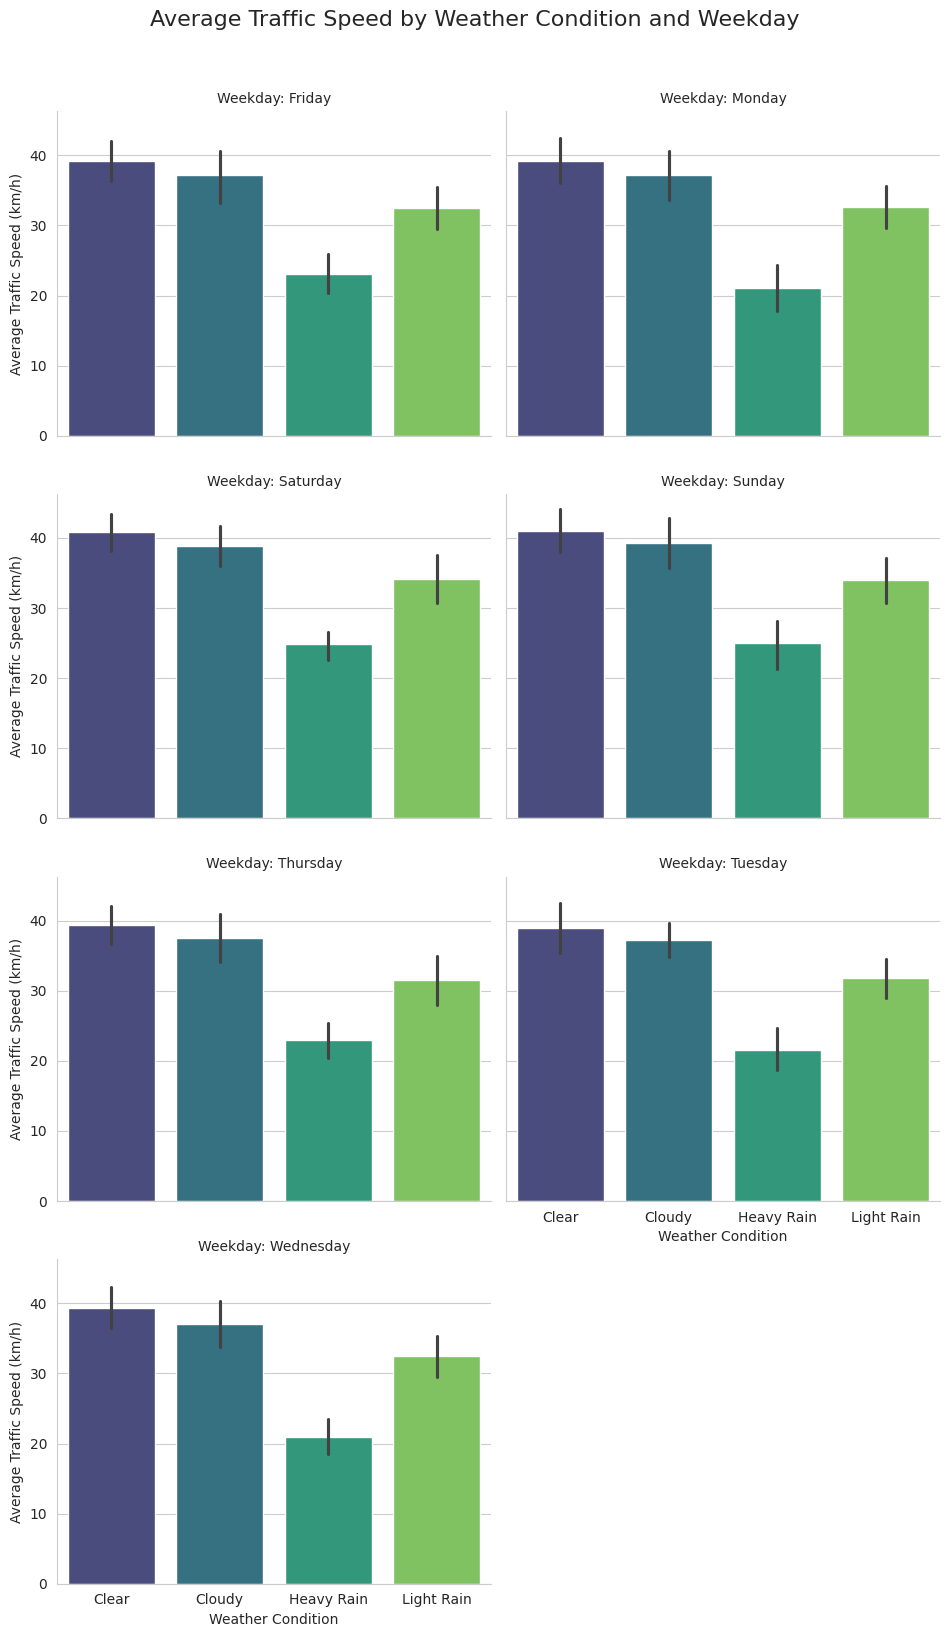

In [17]:
# Visualize average Traffic_Speed by Weather_Condition and Weekday
g = sns.catplot(x='Weather_Condition', y='Traffic_Speed', col='Weekday', data=traffic_patterns_by_temporal, kind='bar', palette='viridis', col_wrap=2, height=4, aspect=1.2, hue='Weather_Condition', legend=False)
g.set_axis_labels("Weather Condition", "Average Traffic Speed (km/h)")
g.set_titles("Weekday: {col_name}")
plt.suptitle('Average Traffic Speed by Weather Condition and Weekday', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

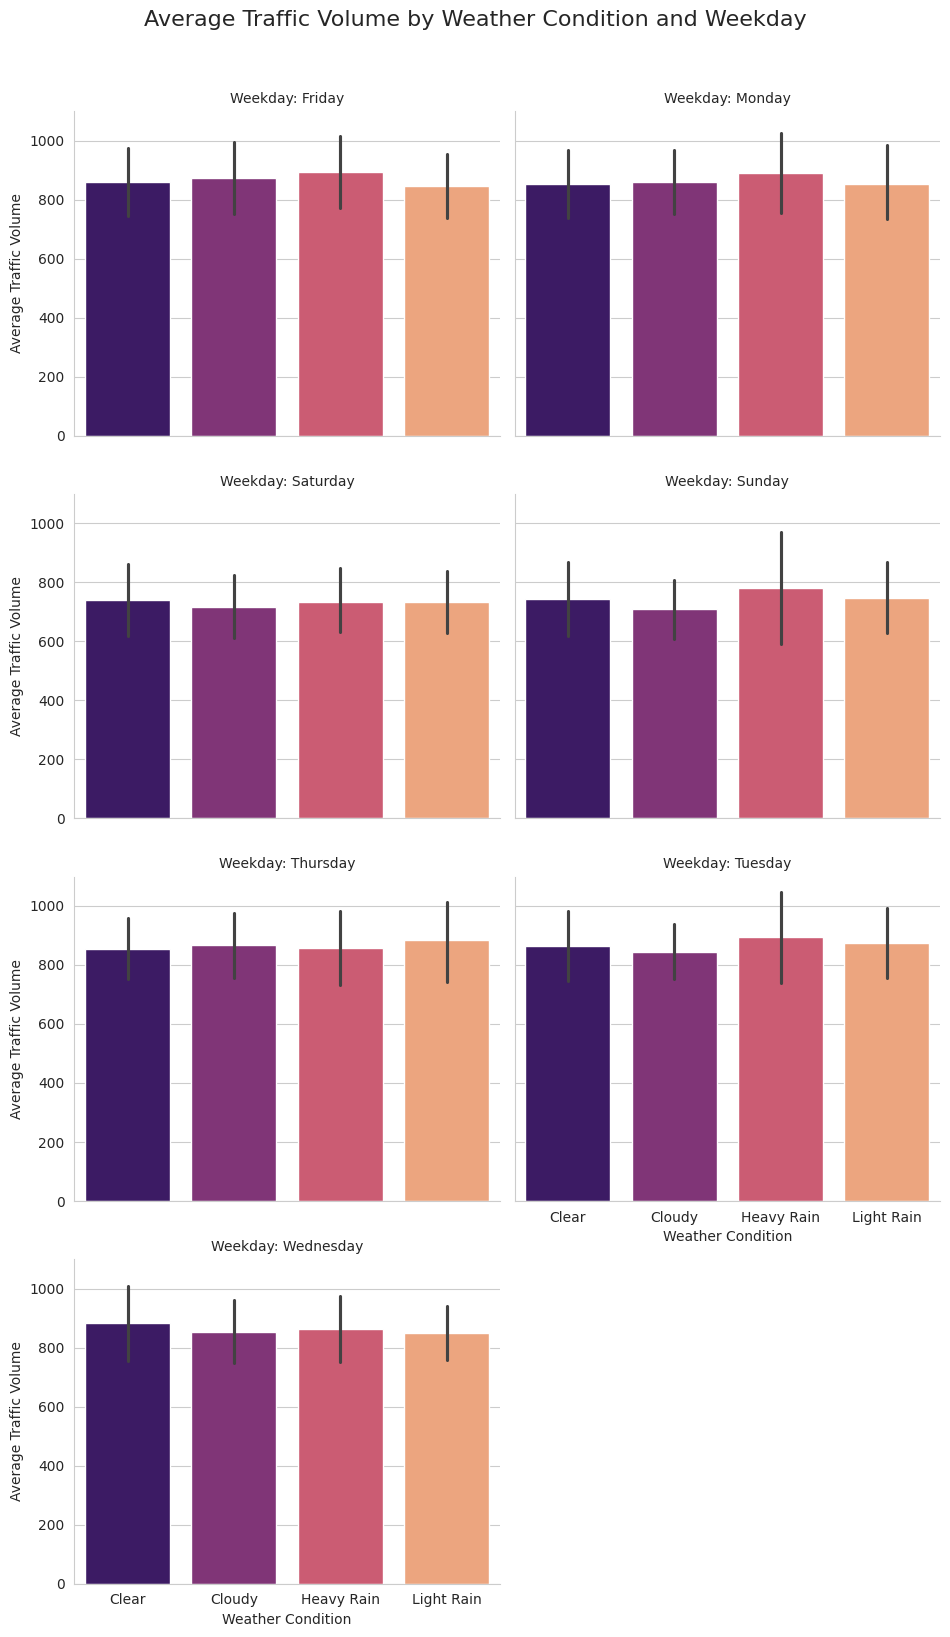

In [18]:
# Visualize average Traffic_Volume by Weather_Condition and Weekday
g = sns.catplot(x='Weather_Condition', y='Traffic_Volume', col='Weekday', data=traffic_patterns_by_temporal, kind='bar', palette='magma', col_wrap=2, height=4, aspect=1.2, hue='Weather_Condition', legend=False)
g.set_axis_labels("Weather Condition", "Average Traffic Volume")
g.set_titles("Weekday: {col_name}")
plt.suptitle('Average Traffic Volume by Weather Condition and Weekday', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Hypothesis Formulation

**Hypothesis:** Heavy rainfall significantly decreases average traffic speed and increases traffic congestion, even when controlling for time of day and weekday, compared to clear or cloudy weather conditions.

This hypothesis suggests that `Rainfall` and `Weather_Condition` are significant factors influencing `Traffic_Speed`, indicating potential congestion. The subsequent analysis will aim to quantify this effect.

## Preparing Data for Decision Tree Model

First, we need to define our target variable for traffic conditions. Given the task of analyzing congestion, we'll create a `Congestion_Level` based on `Traffic_Speed`. We'll categorize traffic speed as 'Low' (indicating congestion) or 'Normal' based on the median traffic speed. Lower speeds typically imply higher congestion.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Define congestion based on Traffic_Speed (e.g., below median speed is 'Low' congestion)
median_traffic_speed = df['Traffic_Speed'].median()
df['Congestion_Level'] = np.where(df['Traffic_Speed'] <= median_traffic_speed, 'Low', 'Normal')

display(df['Congestion_Level'].value_counts())

,count
Congestion_Level,
Low,5000
Normal,5000


Next, we'll prepare the features for the Decision Tree model. This involves one-hot encoding categorical variables and splitting the dataset into training and testing sets.

In [20]:
# Select features and target variable
features = ['Road_ID', 'Weather_Condition', 'Rainfall', 'Time_of_Day', 'Weekday']
X = df[features]
y = df['Congestion_Level']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['Road_ID', 'Weather_Condition', 'Time_of_Day', 'Weekday'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7000, 32)
Shape of X_test: (3000, 32)
Shape of y_train: (7000,)
Shape of y_test: (3000,)


## Training and Evaluating the Decision Tree Model

In [21]:
# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
print("### Decision Tree Classifier Evaluation ###")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

### Decision Tree Classifier Evaluation ###

Classification Report:
              precision    recall  f1-score   support

         Low       0.72      0.72      0.72      1500
      Normal       0.72      0.71      0.72      1500

    accuracy                           0.72      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.72      0.72      0.72      3000


Confusion Matrix:
[[1086  414]
 [ 429 1071]]

Accuracy Score: 0.719
